# Import all necessary libraries

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Load Dataset (Time Series Dataset )

In [8]:
df = pd.read_csv("/content/stock_data.csv")

In [9]:
df

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283
...,...,...,...,...,...,...
360,2020-12-26,92.684784,63.408103,98.288992,117.788079,102.995720
361,2020-12-27,92.688279,62.816639,98.061845,116.605106,102.718260
362,2020-12-28,93.551993,63.597651,96.454800,115.441164,103.566068
363,2020-12-29,93.870037,64.114492,95.747485,113.856107,103.257107


# Basic insight of Dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    object 
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), object(1)
memory usage: 17.2+ KB


In [11]:
df.rename(columns={"Unnamed: 0":"Date"}, inplace=True)

In [12]:
df

,Date,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283
...,...,...,...,...,...,...
360,2020-12-26,92.684784,63.408103,98.288992,117.788079,102.995720
361,2020-12-27,92.688279,62.816639,98.061845,116.605106,102.718260
362,2020-12-28,93.551993,63.597651,96.454800,115.441164,103.566068
363,2020-12-29,93.870037,64.114492,95.747485,113.856107,103.257107


In [13]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [14]:
df

,Date,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283
...,...,...,...,...,...,...
360,2020-12-26,92.684784,63.408103,98.288992,117.788079,102.995720
361,2020-12-27,92.688279,62.816639,98.061845,116.605106,102.718260
362,2020-12-28,93.551993,63.597651,96.454800,115.441164,103.566068
363,2020-12-29,93.870037,64.114492,95.747485,113.856107,103.257107


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     365 non-null    datetime64[ns]
 1   Stock_1  365 non-null    float64       
 2   Stock_2  365 non-null    float64       
 3   Stock_3  365 non-null    float64       
 4   Stock_4  365 non-null    float64       
 5   Stock_5  365 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 17.2 KB


In [16]:
df.isnull().sum()

,0
Date,0
Stock_1,0
Stock_2,0
Stock_3,0
Stock_4,0
Stock_5,0


In [17]:
stock_data = df[['Stock_1']].values

In [18]:
stock_data

array([[101.76405235],
       [102.17126854],
       [103.17125755],
       [105.48321524],
       [107.45317546],
       [106.40305934],
       [107.41398249],
       [107.25140368],
       [107.14070001],
       [107.58061812],
       [107.73558109],
       [109.3023511 ],
       [110.13418323],
       [110.26818901],
       [110.75762896],
       [111.12719874],
       [112.78752696],
       [112.55613402],
       [112.90851093],
       [111.94416414],
       [109.08624103],
       [109.79924899],
       [110.74839345],
       [109.92645761],
       [112.42151846],
       [110.78649849],
       [110.83719275],
       [110.62972342],
       [112.32543283],
       [113.97589643],
       [114.15249914],
       [114.58418111],
       [113.56691908],
       [111.31738956],
       [110.93010284],
       [111.10354091],
       [112.47043742],
       [113.82275929],
       [113.38189322],
       [113.03913664],
       [111.85386142],
       [110.26551653],
       [108.38408889],
       [110

In [19]:
stock_data.shape

(365, 1)

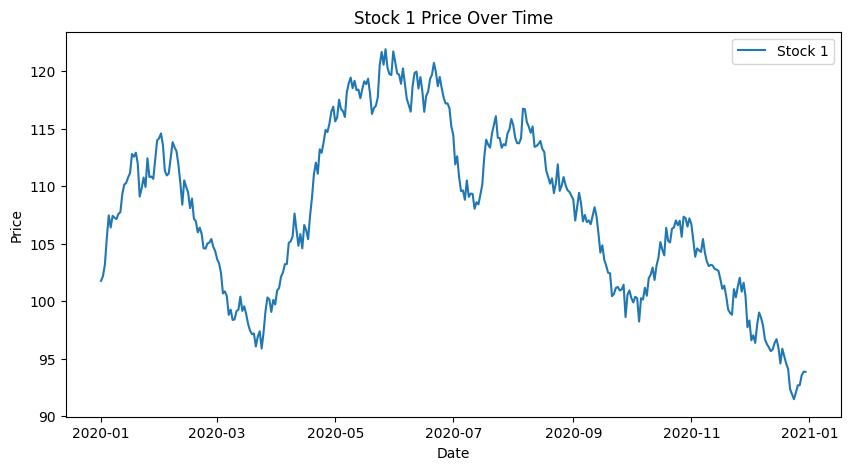

In [27]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Stock_1"], label="Stock 1")

plt.title("Stock 1 Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Scaling

In [28]:
scale = MinMaxScaler()

In [29]:
stock_scaled = scale.fit_transform(stock_data)

In [30]:
stock_scaled

array([[0.33817   ],
       [0.35155324],
       [0.38441807],
       [0.46040099],
       [0.52514411],
       [0.49063184],
       [0.52385602],
       [0.51851284],
       [0.51487454],
       [0.52933254],
       [0.53442542],
       [0.58591762],
       [0.61325594],
       [0.61766006],
       [0.6337456 ],
       [0.64589158],
       [0.70045858],
       [0.69285381],
       [0.70443474],
       [0.6727413 ],
       [0.57881512],
       [0.60224826],
       [0.63344207],
       [0.60642899],
       [0.68842964],
       [0.6346944 ],
       [0.63636048],
       [0.62954196],
       [0.68527177],
       [0.73951457],
       [0.74531865],
       [0.75950596],
       [0.72607345],
       [0.65214224],
       [0.63941398],
       [0.64511406],
       [0.69003737],
       [0.73448169],
       [0.71999254],
       [0.70872778],
       [0.66977348],
       [0.61757223],
       [0.55573875],
       [0.62522661],
       [0.60671833],
       [0.59089052],
       [0.54582477],
       [0.573

# Making the Sequence

In [32]:
def create_seq(data, seq_len=3):
  x,y=[],[]
  for i in range(len(data)-seq_len):
    x.append(data[i:i+seq_len])
    y.append(data[i+seq_len])
  return np.array(x), np.array(y)

In [33]:
x, y = create_seq(stock_scaled, seq_len=3)

In [34]:
x.shape

(362, 3, 1)

In [35]:
y

array([[0.46040099],
       [0.52514411],
       [0.49063184],
       [0.52385602],
       [0.51851284],
       [0.51487454],
       [0.52933254],
       [0.53442542],
       [0.58591762],
       [0.61325594],
       [0.61766006],
       [0.6337456 ],
       [0.64589158],
       [0.70045858],
       [0.69285381],
       [0.70443474],
       [0.6727413 ],
       [0.57881512],
       [0.60224826],
       [0.63344207],
       [0.60642899],
       [0.68842964],
       [0.6346944 ],
       [0.63636048],
       [0.62954196],
       [0.68527177],
       [0.73951457],
       [0.74531865],
       [0.75950596],
       [0.72607345],
       [0.65214224],
       [0.63941398],
       [0.64511406],
       [0.69003737],
       [0.73448169],
       [0.71999254],
       [0.70872778],
       [0.66977348],
       [0.61757223],
       [0.55573875],
       [0.62522661],
       [0.60671833],
       [0.59089052],
       [0.54582477],
       [0.57344239],
       [0.51566861],
       [0.50817591],
       [0.476

In [36]:
x.shape[0]

362

In [37]:
x.shape[1]

3

In [38]:
x.shape

(362, 3, 1)

In [39]:
x = x.reshape(x.shape[0], x.shape[1], 1)

In [40]:
x.shape

(362, 3, 1)

In [41]:
x

array([[[0.33817   ],
        [0.35155324],
        [0.38441807]],

       [[0.35155324],
        [0.38441807],
        [0.46040099]],

       [[0.38441807],
        [0.46040099],
        [0.52514411]],

       ...,

       [[0.01864999],
        [0.03977814],
        [0.039893  ]],

       [[0.03977814],
        [0.039893  ],
        [0.06827913]],

       [[0.039893  ],
        [0.06827913],
        [0.07873171]]])

In [42]:
x.shape[1]

3

In [43]:
x.shape[2]

1

# building a model with LSTM

> Add blockquote



In [44]:
model = Sequential()
model.add(LSTM(32, activation='relu', input_shape=(3,1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
model.compile(
    optimizer='adam',
    loss='mse'

)

In [46]:
model.fit(x,y, epochs=50, verbose=1)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3463
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3051
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2633
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2287
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1657 
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1285 
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0860 
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0489 
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0217 
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097 
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062 
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040 
Epoch 13/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 
Epoch 14/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020 
Epoch 15/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 
Epoch 16

In [47]:
x

array([[[0.33817   ],
        [0.35155324],
        [0.38441807]],

       [[0.35155324],
        [0.38441807],
        [0.46040099]],

       [[0.38441807],
        [0.46040099],
        [0.52514411]],

       ...,

       [[0.01864999],
        [0.03977814],
        [0.039893  ]],

       [[0.03977814],
        [0.039893  ],
        [0.06827913]],

       [[0.039893  ],
        [0.06827913],
        [0.07873171]]])

# Model Prediction and Evaluation

In [49]:
pred = model.predict(x)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [54]:
mse = mean_squared_error(y, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, pred)


In [55]:

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.001772850481722684
RMSE: 0.042105231049392
MAE: 0.03384395592771089


In [50]:
pred_rescaled = scale.inverse_transform(pred)
actual = scale.inverse_transform(y)

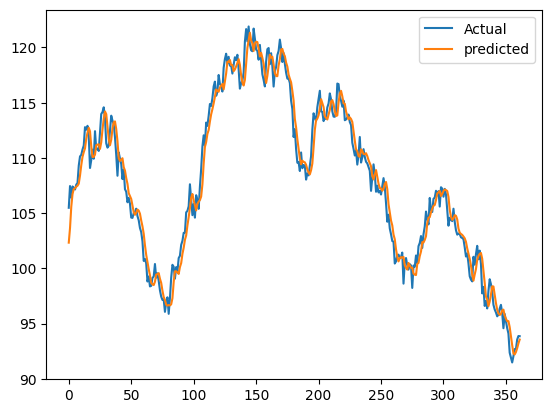

In [51]:
plt.plot(actual,label='Actual')
plt.plot(pred_rescaled,label="predicted")
plt.legend()
plt.show()

# Stock 1 Prediction (multiveriate LSTM)

## Basic insight of the dataset

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     365 non-null    datetime64[ns]
 1   Stock_1  365 non-null    float64       
 2   Stock_2  365 non-null    float64       
 3   Stock_3  365 non-null    float64       
 4   Stock_4  365 non-null    float64       
 5   Stock_5  365 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 17.2 KB


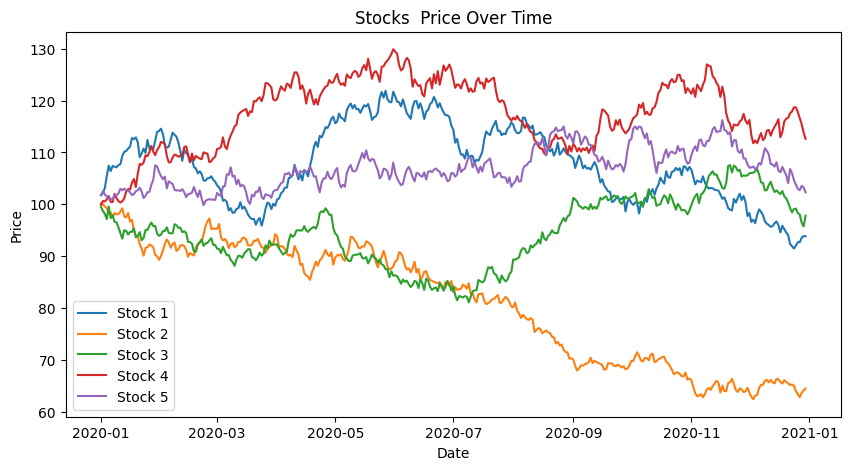

In [61]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Stock_1"], label="Stock 1")
plt.plot(df["Date"], df["Stock_2"], label="Stock 2")
plt.plot(df["Date"], df["Stock_3"], label="Stock 3")
plt.plot(df["Date"], df["Stock_4"], label="Stock 4")
plt.plot(df["Date"], df["Stock_5"], label="Stock 5")
plt.title("Stocks  Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [62]:
feature = df[['Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5']].values

In [63]:
feature.shape

(365, 5)

In [64]:
feature

array([[101.76405235, 100.16092817,  99.49464168,  99.90975615,
        101.76126613],
       [102.17126854,  99.96996786,  98.68297281, 100.6407548 ,
        102.52864342],
       [103.17125755,  99.57523693,  98.18213935, 100.57484681,
        101.88781132],
       ...,
       [ 93.55199344,  63.59765079,  96.45480014, 115.44116369,
        103.56606819],
       [ 93.87003746,  64.11449239,  95.74748474, 113.85610739,
        103.25710661],
       [ 93.85531666,  64.49101076,  97.80564828, 112.6404179 ,
        102.30422596]])

In [65]:
scaler = MinMaxScaler()

In [66]:
feature_scaled = scaler.fit_transform(feature)

In [67]:
feature_scaled

array([[0.33817   , 1.        , 0.69431017, 0.        , 0.1174832 ],
       [0.35155324, 0.99494101, 0.66365448, 0.0243653 , 0.16424457],
       [0.38441807, 0.98448365, 0.64473864, 0.02216848, 0.12519443],
       ...,
       [0.06827913, 0.03135192, 0.57949926, 0.51768546, 0.22746173],
       [0.07873171, 0.04504428, 0.55278486, 0.46485312, 0.20863466],
       [0.07824791, 0.05501915, 0.63051906, 0.42433234, 0.15056933]])

# Making Sequence

In [76]:
# function
def make_seq(data, seq_len=3):
  x,y=[],[]
  for i in range(len(data)-3):
    x.append(data[i:i+seq_len])
    y.append(data[i+seq_len])
  return np.array(x),np.array(y)

In [77]:
x, y = make_seq(feature, 3)

In [78]:
x.shape

(362, 3, 5)

# LSTM Model building

In [79]:
model_multi = Sequential()
model_multi.add(LSTM(12,activation='relu', input_shape=(3,5)))
model_multi.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [80]:
model_multi.compile(optimizer='adam', loss='mse')


In [81]:
model_multi.fit(x,y,epochs=50, verbose=1)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 33572.5859
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13520.7881 
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6854.2974 
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3740.3191 
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2308.4409 
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1397.5502 
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 817.2911 
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 467.6935 
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 310.2588 
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 255.1354 
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 227.8995 
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 230.0578 
Epoch 13/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 223.5627 
Epoch 14/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 225.4204 
Epoch 15/50
12/12 ━━━━━━━━━━━━━━━━━━

# Model Evaluation

In [83]:
pred_multi= model_multi.predict(x)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


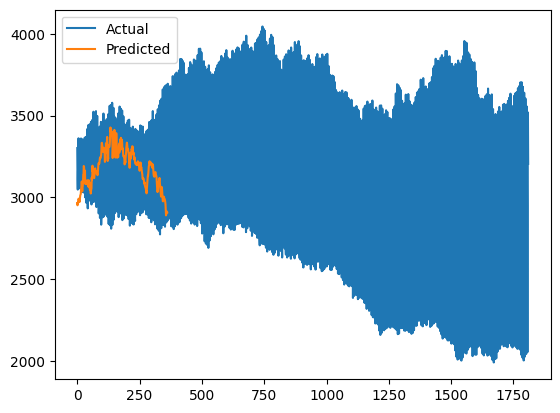

In [84]:
# Rescale only Stock_1 predictions
stock1_scaler = MinMaxScaler()
stock1_scaler.min_, stock1_scaler.scale_ = scaler.min_[0], scaler.scale_[0]
pred_multi_rescaled = stock1_scaler.inverse_transform(pred_multi.reshape(-1,1))
actual_multi_rescaled = stock1_scaler.inverse_transform(y.reshape(-1,1))

# Plot
plt.plot(actual_multi_rescaled, label="Actual")
plt.plot(pred_multi_rescaled, label="Predicted")
plt.legend()
plt.show()